<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/Logistic_Regression_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Desese Prediction

**Data Preparation**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report


In [18]:
# reading csv file
df = pd.read_csv("heart.csv")

In [19]:
# displayinf first 5 rows
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Cleaning**

In [20]:
# remove duplicate rows
df.drop_duplicates(inplace=True)

In [21]:
# identifying null values
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0


In [22]:
# remove unwanted columns
df = df.drop("Unnamed: 0",axis=1)

In [23]:
# checking age column
df["age"].unique()

array([63, 37, 41, 56, 57, 44, 52, 54, 48, 49, 64, 58, 50, 66, 43, 69, 59,
       42, 61, 40, 71, 51, 65, 53, 46, 45, 39, 47, 62, 34, 35, 29, 55, 60,
       67, 68, 74, 76, 70, 38, 77])

In [24]:
# checking sex column
df["sex"].unique()

array([1, 0])

# EDA

<Axes: xlabel='sex', ylabel='count'>

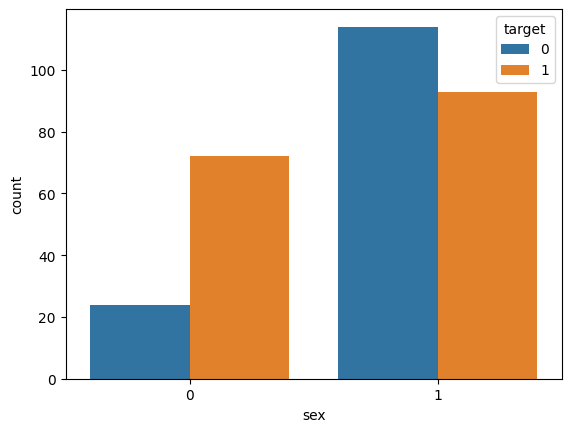

In [25]:
# which gender got more heart disease

sns.countplot(x="sex",hue="target",data=df)


<Axes: xlabel='trestbps', ylabel='Count'>

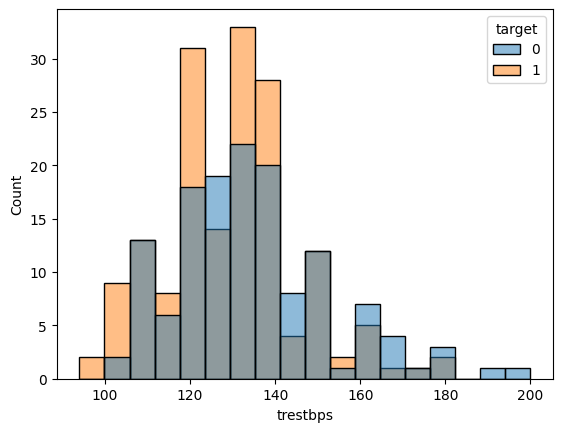

In [26]:
# check in which range of bp heart diseases are more
sns.histplot(x="trestbps",hue="target",data=df)

<Axes: xlabel='thalach', ylabel='Count'>

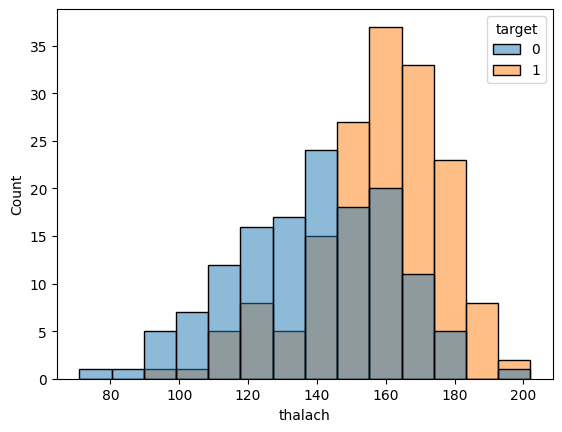

In [27]:
# check for which hear rate heart disese is more
sns.histplot(x="thalach",hue="target",data=df)


# Model Training

In [28]:
# divide input and output columns
X = df.drop("target",axis=1)
y = df.target

In [29]:
# split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [31]:
# model training
model = LogisticRegression()
model.fit(Xtrain,ytrain)

LogisticRegression()

# Prediction

In [32]:
# predict the model
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1])

In [33]:
# print confusion matrix
confusion_matrix(ytest,ypred)

array([[32,  9],
       [ 8, 42]])

In [34]:
# print classification report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [35]:
# Testing and training efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.8726415094339622
Testing Eff:  0.8131868131868132
